# 02 — Compare two planners

This notebook runs the **same scenario** with **two different planners**
and compares their outcomes side by side.

The two planners are:

- **`simple_policy`** — a built-in goal-seeking policy that steers the
  robot toward its goal.
- **`random`** — a random policy that ignores the goal (a control/baseline).

We reuse the benchmark episode runner
(`robot_sf.benchmark.runner.run_episode`), which loads each planner from
the baseline registry, builds observations, translates actions, and
computes a rich metrics dictionary. **No new logic is added** — we only
call the existing public API and chart the results.

> CPU-only, deterministic (fixed seed), no model weights required.
>
> The metrics here are a small illustrative sample for a single seed —
> they are **not** a benchmark result.

In [1]:
import os
import sys
from IPython import get_ipython

os.environ.setdefault("SDL_VIDEODRIVER", "dummy")


def _inline_matplotlib() -> None:
    # (Re-)arm the notebook inline backend for the next figure.
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("matplotlib", "inline")


# Keep log output quiet so the executed notebook stays readable.
from loguru import logger
logger.remove()
logger.add(sys.stderr, level="ERROR")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from robot_sf.training.scenario_loader import load_scenarios
from robot_sf.benchmark.runner import run_episode
from robot_sf.baselines import list_baselines

# Resolve the repo root robustly regardless of launch directory.
def _repo_root() -> Path:
    here = Path.cwd()
    for candidate in [here, *here.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return here

REPO_ROOT = _repo_root()

OUTPUT_DIR = REPO_ROOT / "output/notebooks/02_compare_two_planners"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO_ROOT)
print("Artifacts will be written to:", OUTPUT_DIR.relative_to(REPO_ROOT))

I0000 00:00:1784157904.579386 1036915 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784157904.610802 1036915 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784157905.183786 1036915 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784157905.183983 1036915 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Repo root: /home/luttkule/git/robot_sf_ll7.worktrees/cheap-issue-5798-20260715T225820Z
Artifacts will be written to: output/notebooks/02_compare_two_planners


## 1. Load the shared scenario

We use the bundled `quickstart_demo_crossing_basic` scenario so both planners face the identical situation.

In [2]:
SCENARIO_PATH = REPO_ROOT / "configs/scenarios/single/quickstart_demo.yaml"
SCENARIO_NAME = "quickstart_demo_crossing_basic"

scenarios = load_scenarios(SCENARIO_PATH)
scenario = next(s for s in scenarios if s["name"] == SCENARIO_NAME)
print("Loaded scenario:", scenario["name"])
print("Map file:", scenario.get("map_file"))
print("Registered baseline planners:", sorted(list_baselines()))
print("(plus the built-in goal-seeker known as 'simple_policy' / 'goal')")

Loaded scenario: quickstart_demo_crossing_basic
Map file: ../../../maps/svg_maps/francis2023/francis2023_circular_crossing.svg
Registered baseline planners: ['baseline_sf', 'brne', 'dr_mpc', 'drl_vo', 'orca', 'ppo', 'random', 'sac', 'sicnav', 'social_force']
(plus the built-in goal-seeker known as 'simple_policy' / 'goal')


## 2. Run each planner for one episode

`run_episode` returns a record whose `metrics` dictionary contains the
quantities we compare. We keep the horizon short so the notebook stays
fast.

In [3]:
SEED = 270
HORIZON = 60
DT = 0.1
PLANNERS = ["simple_policy", "random"]

records = {}
for algo in PLANNERS:
    rec = run_episode(scenario, SEED, horizon=HORIZON, dt=DT, algo=algo)
    records[algo] = rec
    m = rec["metrics"]
    print(
        f"{algo:>14s}: steps={rec['steps']:>3d}  "
        f"collisions={int(m['collisions']):>2d}  "
        f"avg_speed={float(m['avg_speed']):.3f}  "
        f"path_length={float(m['socnavbench_path_length']):.2f}  "
        f"success={bool(m['success'])}"
    )

 simple_policy: steps= 60  collisions=27  avg_speed=0.984  path_length=6.00  success=False


        random: steps= 60  collisions= 0  avg_speed=0.910  path_length=5.55  success=False


## 3. Compare key metrics

We chart four beginner-friendly metrics for both planners:

| Metric | Meaning |
| --- | --- |
| `collisions` | Number of pedestrian/obstacle collisions in the episode |
| `avg_speed` | Mean robot speed (m/s) |
| `socnavbench_path_length` | Total path length travelled (m) |
| `path_efficiency` | Ratio of straight-line to actual path (1.0 = perfectly direct) |

Saved: output/notebooks/02_compare_two_planners/planner_comparison.png


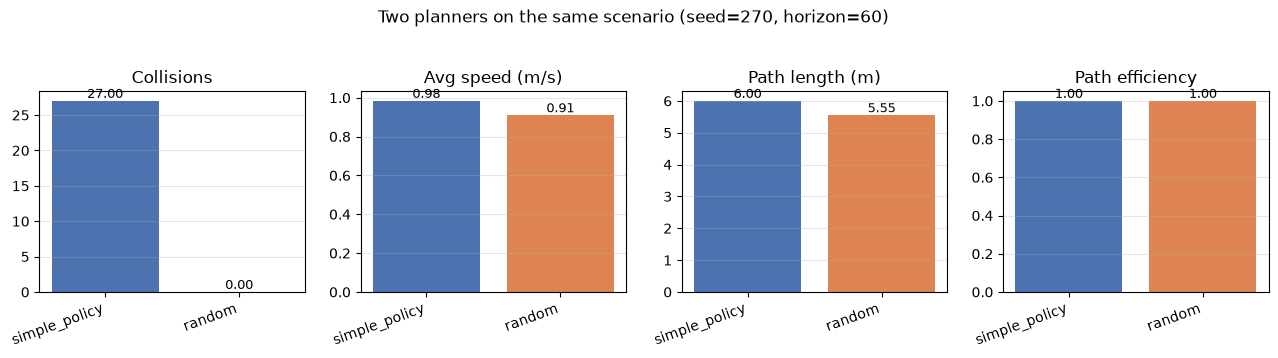

In [4]:
metric_keys = ["collisions", "avg_speed", "socnavbench_path_length", "path_efficiency"]
metric_labels = ["Collisions", "Avg speed (m/s)", "Path length (m)", "Path efficiency"]

values = np.array(
    [[float(records[a]["metrics"][k]) for k in metric_keys] for a in PLANNERS],
    dtype=float,
)

_inline_matplotlib()
fig, axes = plt.subplots(1, len(metric_keys), figsize=(13, 3.4))
x = np.arange(len(PLANNERS))
for j, (ax, label) in enumerate(zip(axes, metric_labels)):
    ax.bar(x, values[:, j], color=["#4C72B0", "#DD8452"])
    ax.set_xticks(x)
    ax.set_xticklabels(PLANNERS, rotation=20, ha="right")
    ax.set_title(label)
    ax.grid(True, axis="y", alpha=0.3)
    for xi, vi in zip(x, values[:, j]):
        ax.text(xi, vi, f"{vi:.2f}", ha="center", va="bottom", fontsize=9)
fig.suptitle(f"Two planners on the same scenario (seed={SEED}, horizon={HORIZON})", y=1.04)
fig.tight_layout()
plot_path = OUTPUT_DIR / "planner_comparison.png"
fig.savefig(plot_path, dpi=120, bbox_inches="tight")
print("Saved:", plot_path.relative_to(REPO_ROOT))
plt.show()

## 4. Summary table

A compact, machine-readable comparison written to `output/` alongside the
figure.

In [5]:
import json

summary = {
    "schema_version": "robot_sf_notebook_02_planner_compare.v1",
    "scenario": SCENARIO_NAME,
    "seed": SEED,
    "horizon": HORIZON,
    "dt": DT,
    "claim_boundary": (
        "Single-seed illustrative comparison for a beginner notebook; "
        "not a benchmark result."
    ),
    "planners": {
        algo: {
            k: records[algo]["metrics"][k] for k in metric_keys
        }
        for algo in PLANNERS
    },
}
summary_path = OUTPUT_DIR / "comparison_summary.json"
summary_path.write_text(json.dumps(summary, indent=2) + "\n", encoding="utf-8")
print("Saved:", summary_path.relative_to(REPO_ROOT))
print(json.dumps(summary["planners"], indent=2))

Saved: output/notebooks/02_compare_two_planners/comparison_summary.json
{
  "simple_policy": {
    "collisions": 27,
    "avg_speed": 0.9836065573770492,
    "socnavbench_path_length": 5.999999999999993,
    "path_efficiency": 1.0
  },
  "random": {
    "collisions": 0,
    "avg_speed": 0.9096203392707587,
    "socnavbench_path_length": 5.548684069551628,
    "path_efficiency": 1.0
  }
}


## Interpretation

- The **goal-seeker** (`simple_policy`) usually travels further and faster
  because it actively aims for the goal — but on a crowded map it may
  collide with pedestrians along the way.
- The **random** planner wanders without purpose, so it tends to stall,
  cover less ground, and time out — but without committing to a direction
  it may also happen to avoid collisions.

The exact numbers depend on the seed and the single short horizon; this is
a teaching comparison, not a rigorous evaluation. To draw real conclusions
you would repeat over many seeds and scenarios (see the benchmark tooling
under `scripts/benchmark*`).

Next: **03 — Visualize a trace**.